# Сессионное задание: Кластеризация сигналов сцинтилляционного детектора
### Kaggle: Signal Types Classification

**Цель:** Разделить 23 479 сигналов на три кластера:
- **Кластер 0** - гамма-кванты или нейтроны (тип 1)
- **Кластер 1** - второй тип частиц
- **Кластер 2** - аномальные / неидентифицируемые сигналы

**Метод:** Обучение без учителя (unsupervised learning)

Ссылка на соревнование: https://www.kaggle.com/competitions/signal-types-classification


#### Автор: Когай Сергей

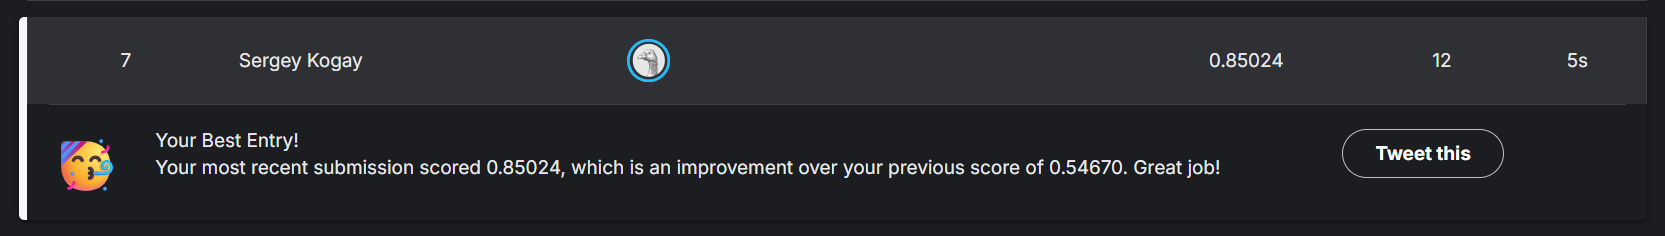


## Установка зависимостей и импорты

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score

sns.set_style('whitegrid')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Загрузка данных

In [2]:
df = pd.read_csv('Run200_Wave_0_1.txt', sep=' ', header=None, skipinitialspace=True)
df = df.drop([0, 1, 2, 3, 504], axis=1)
df.columns = list(range(500))
df.head()

print(f'Размер данных: {df.shape}')

Размер данных: (23479, 500)


In [3]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,490,491,492,493,494,495,496,497,498,499
0,14820,14823,14824,14822,14818,14820,14824,14822,14820,14820,...,14828,14822,14815,14815,14817,14819,14820,14822,14820,14819
1,14820,14822,14820,14826,14824,14822,14820,14822,14823,14821,...,14828,14817,14824,14822,14824,14819,14820,14819,14822,14820
2,14820,14820,14822,14825,14820,14824,14824,14819,14823,14824,...,14820,14821,14820,14820,14818,14821,14823,14820,14820,14821
3,14828,14822,14818,14824,14824,14822,14820,14822,14824,14820,...,14824,14826,14822,14821,14820,14828,14820,14822,14823,14822
4,14823,14815,14823,14821,14827,14820,14823,14824,14816,14821,...,14820,14820,14823,14828,14824,14820,14824,14824,14822,14825


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23479 entries, 0 to 23478
Columns: 500 entries, 0 to 499
dtypes: int64(500)
memory usage: 89.6 MB


In [5]:
df.describe().T.head()

,count,mean,std,min,25%,50%,75%,max
0,23479.0,14822.972316,2.805884,14812.0,14821.0,14823.0,14824.0,14834.0
1,23479.0,14822.958474,2.833516,14812.0,14821.0,14823.0,14824.0,14835.0
2,23479.0,14822.970016,2.840755,14812.0,14821.0,14823.0,14825.0,14834.0
3,23479.0,14822.989991,2.852066,14811.0,14821.0,14823.0,14825.0,14835.0
4,23479.0,14823.003961,2.833412,14812.0,14821.0,14823.0,14825.0,14834.0


В датасете 23479 сигналов, каждый описывается 500 признаками

* все признаки примерно в диапазоне 14810–14835
* среднее почти одинаковое (~14823)
* 25%, 50%, 75% почти совпадают

## Исследование данных

In [6]:
missing_values = df.isnull().sum()
total_rows = len(df)

missing_data = missing_values[missing_values > 0].to_frame(name="Missing Count")
missing_data["Missing Percentage"] = (missing_data["Missing Count"] / total_rows) * 100

print(f'Размер данных: {df.shape}')
print(missing_data if missing_values.any() else 'Пропусков нет!')

Размер данных: (23479, 500)
Пропусков нет!


In [7]:
print("Проверка на дубликаты:", df.duplicated().sum())

Проверка на дубликаты: 0


In [8]:
const_cols = [col for col in df.columns if df[col].nunique() <= 1]
print("Проверка на константы:", len(const_cols))
print(const_cols[:20])

if const_cols:
    df = df.drop(columns=const_cols)
    print("После удаления констант:", df.shape)

Проверка на константы: 0
[]


Text(0, 0.5, 'bit ADC')

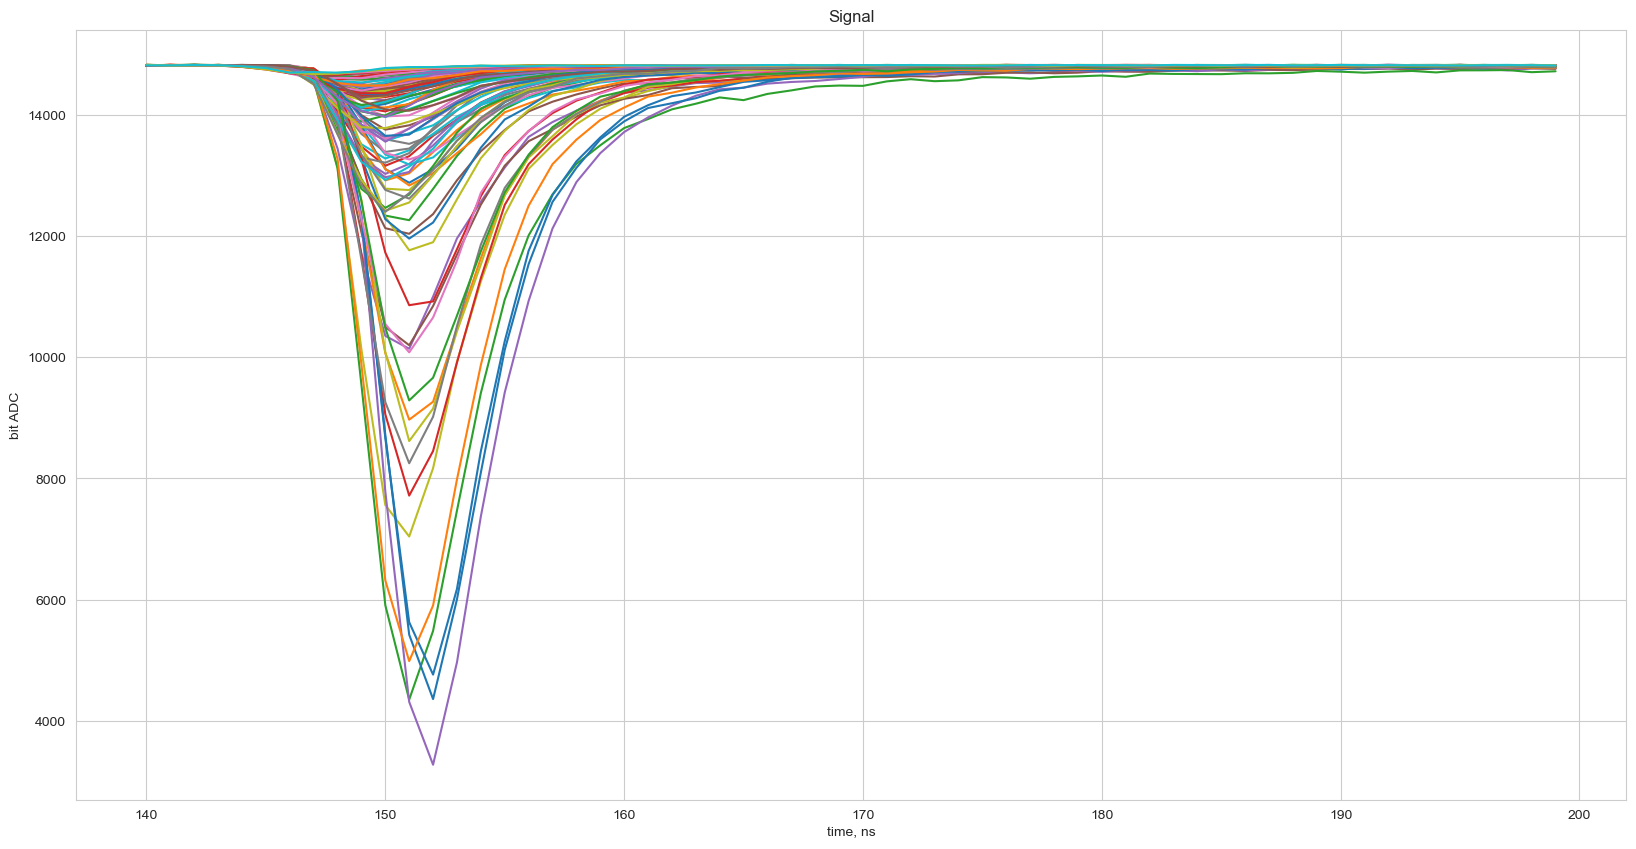

In [9]:
N=range(0,100)
ax = df.T[N][140:200].plot(title='Signal' ,legend=None,figsize=(20,10))
ax.set_xlabel("time, ns")
ax.set_ylabel("bit ADC")

Text(0, 0.5, 'bit ADC')

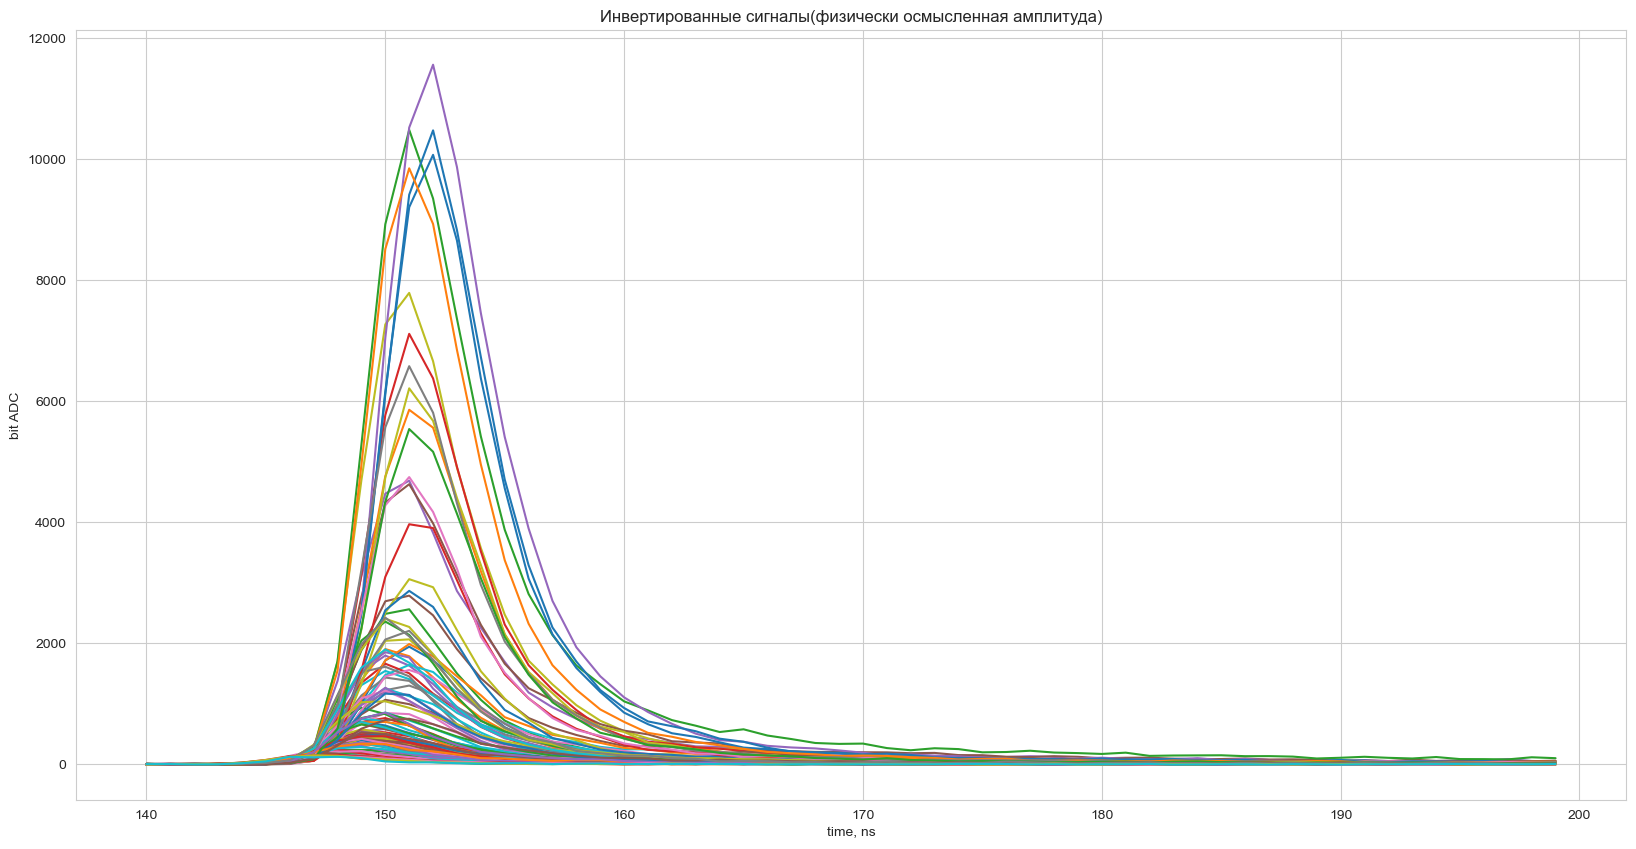

In [10]:
ax = (2**14-df.T[N]-1560)[140:200].plot(title='Signal' ,legend=None,figsize=(20,10))
ax.set_title('Инвертированные сигналы(физически осмысленная амплитуда)')
ax.set_xlabel("time, ns")
ax.set_ylabel("bit ADC")

## Подготовка формы сигнала

```python
X_signal = 2**14 - raw_signal - 1560
```

После преобразование импульсы становятся положительными, что удобно для расчёта амплитуды, площади, PSD и времени спада.

In [11]:
X = df.astype('float32')
X_signal = (2**14 - X - 1560).to_numpy(dtype=np.float32)

## Вычисление признаков

In [12]:
# Константы для расчёта признаков
NOISE_WINDOW = 140       # число отсчётов для оценки шума
SIGMA_THRESH = 3.0       # порог в сигмах шума
K_END_POINTS = 3         # число подряд идущих точек ниже порога для конца сигнала
LONG_OFFSET = 3          # сдвиг начала длинного окна от пика
SHORT_LENGTH = 4         # длина короткого окна

def find_signal_end(y, peak_idx, noise_std):
    """
    Определяет конец сигнала для каждой формы.
    Конец – момент, когда K_END_POINTS подряд отсчётов
    становятся <= SIGMA_THRESH * noise_std после пика.
    """
    n_signals, length = y.shape
    end = np.full(n_signals, length - 1, dtype=np.int32)
    threshold = SIGMA_THRESH * noise_std
    for i in range(n_signals):
        run = 0
        for j in range(peak_idx[i], length):
            if y[i, j] <= threshold[i]:
                run += 1
                if run >= K_END_POINTS:
                    end[i] = max(j - K_END_POINTS + 1, peak_idx[i])
                    break
            else:
                run = 0
    return end

def integrate_interval(y, peak_idx, end, offset, length=None):
    """
    Интегрирует сигнал в окне [peak+offset, ...].
    Если length задан – окно фиксированной длины,
    иначе до end. Отрицательные значения обнуляются.
    """
    n_signals = y.shape[0]
    result = np.zeros(n_signals)
    for i in range(n_signals):
        start = peak_idx[i] + offset
        stop = end[i] + 1 if length is None else min(start + length, end[i] + 1)
        if start < stop:
            window = y[i, start:stop]
            result[i] = np.clip(window, 0, None).sum()
    return result

def build_features(X_inv, RAW_orig):
    """Формирует DataFrame с признаками для всех сигналов."""
    # Оценка шума по первым NOISE_WINDOW отсчётам
    baseline = X_inv[:, :NOISE_WINDOW].mean(axis=1)
    noise_std = X_inv[:, :NOISE_WINDOW].std(axis=1) + 1e-6

    # Убираем пьедестал
    y = X_inv - baseline[:, None]

    # Положение и значение максимума
    peak = y.argmax(axis=1).astype(np.int32)
    amplitude = y[np.arange(len(y)), peak].clip(1e-6)

    # Конец сигнала
    end = find_signal_end(y, peak, noise_std)

    # Заряды в длинном и коротком окнах
    long_area = integrate_interval(y, peak, end, LONG_OFFSET) + 1e-6
    short_area = integrate_interval(y, peak, end, 0, length=SHORT_LENGTH) + 1e-6

    # Признаки
    psd = (long_area - short_area) / long_area
    tail_length = end - peak + 1
    log_ratio = np.log10(amplitude / long_area)
    saturated = (amplitude >= 14000) | (RAW_orig == 0).any(axis=1)

    return pd.DataFrame({
        'baseline': baseline,
        'noise_std': noise_std,
        'peak_idx': peak,
        'end_idx': end,
        'amplitude': amplitude,
        'long_area': long_area,
        'short_area': short_area,
        'psd': psd,
        'tail_length': tail_length,
        'log_ratio': log_ratio,
        'saturated': saturated,
    })

features = build_features(X_signal, X)
print('Признаки построены. Размер таблицы:', features.shape)
features.head()

Признаки построены. Размер таблицы: (23479, 11)


,baseline,noise_std,peak_idx,end_idx,amplitude,long_area,short_area,psd,tail_length,log_ratio,saturated
0,3.035714,2.731852,149,202,529.964294,1900.178468,1622.857179,0.145945,54,-0.554548,False
1,1.742857,2.718643,150,188,1901.257202,4316.257814,6189.028810,-0.433888,39,-0.356067,False
2,2.150000,2.416979,151,200,2557.850098,4580.950196,7160.400392,-0.563082,50,-0.253080,False
3,1.400000,2.776947,149,189,564.599976,1901.799928,1896.399903,0.002839,41,-0.527424,False
4,2.500000,2.676619,150,182,1793.500000,3862.000001,5691.000001,-0.473589,33,-0.333111,False


Получено 11 признаков; уже на первых наблюдениях видно, что psd разделяет сигналы на две группы (положительный — короткий хвост, отрицательный — длинный), что соответствует предварительному разделению типов частиц.

## Разведочный анализ данных (EDA)

                 mean       std      min       50%        max
amplitude    1835.102  2389.307  104.307   812.807  14824.600
long_area    4896.082  6055.655   71.357  2306.250  51153.430
psd            -0.232     0.397   -3.850    -0.194      0.416
tail_length    53.303    40.061    8.000    40.000    271.000
noise_std       2.703     0.165    2.087     2.700      9.486
log_ratio      -0.424     0.157   -0.796    -0.417      0.385


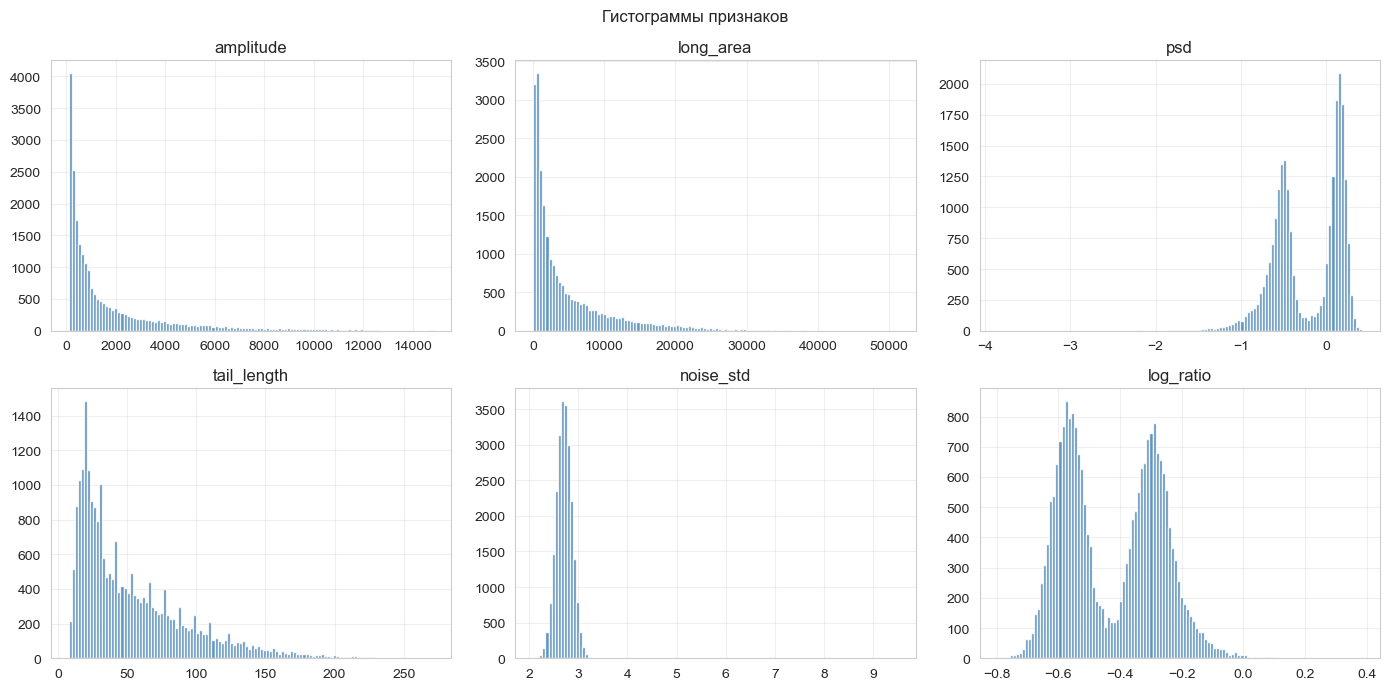

In [13]:
feature_cols = ['amplitude', 'long_area', 'psd', 'tail_length', 'noise_std', 'log_ratio']
print(features[feature_cols].describe().T[['mean', 'std', 'min', '50%', 'max']].round(3))

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.ravel(), feature_cols):
    ax.hist(features[col].dropna(), bins=120, color='steelblue', alpha=0.85)
    ax.set_title(col)
    ax.grid(alpha=0.3)
plt.suptitle('Гистограммы признаков')
plt.tight_layout()
plt.show()

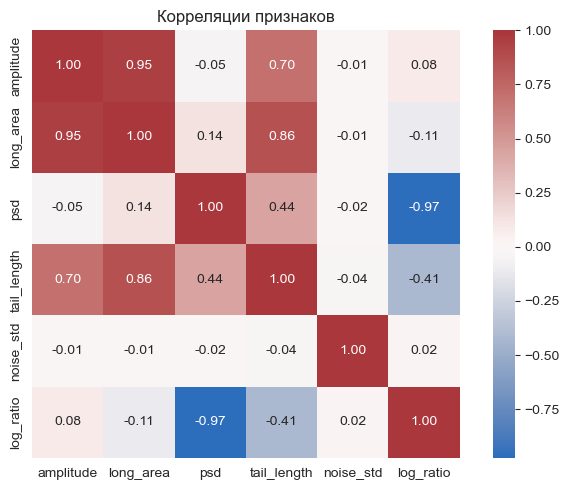

In [14]:
corr = features[feature_cols].corr()
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='vlag', center=0, square=True)
plt.title('Корреляции признаков')
plt.tight_layout()
plt.show()

#### Вывод: 
Признаки имеют выраженную асимметрию и физически интерпретируемое распределение: psd лучше всего разделяет типы частиц, а log_ratio помогает выделять аномальные события, тогда как остальные признаки в основном отражают масштаб и форму сигналов.

## Сравнение моделей кластеризации

In [15]:
main_cols = ['psd', 'log_ratio']
F2 = StandardScaler().fit_transform(features[main_cols].to_numpy())

# Подвыборка 5000 объектов
N = len(F2)
sub_idx = np.random.default_rng(RANDOM_STATE).choice(N, size=min(5000, N), replace=False)
X_sub = F2[sub_idx]

models = {
    'KMeans(k=2)': KMeans(
        n_clusters=2,
        n_init=10,
        random_state=RANDOM_STATE
    ),

    'KMeans(k=3)': KMeans(
        n_clusters=3,
        n_init=10,
        random_state=RANDOM_STATE
    ),

    'KMeans(k=4)': KMeans(
        n_clusters=4,
        n_init=10,
        random_state=RANDOM_STATE
    ),

    'GMM(k=2, full)': GaussianMixture(
        n_components=2,
        covariance_type='full',
        n_init=5,
        random_state=RANDOM_STATE
    ),

    'GMM(k=2, tied)': GaussianMixture(
        n_components=2,
        covariance_type='tied',
        n_init=5,
        random_state=RANDOM_STATE
    ),

    'GMM(k=2, diag)': GaussianMixture(
        n_components=2,
        covariance_type='diag',
        n_init=5,
        random_state=RANDOM_STATE
    ),

    'GMM(k=3, full)': GaussianMixture(
        n_components=3,
        covariance_type='full',
        n_init=5,
        random_state=RANDOM_STATE
    ),
    
    'Agglom(k=2, ward)': AgglomerativeClustering(
        n_clusters=2,
        linkage='ward'
    ),

    'Agglom(k=2, avg)': AgglomerativeClustering(
        n_clusters=2,
        linkage='average'
    ),

    'Agglom(k=3, ward)': AgglomerativeClustering(
        n_clusters=3,
        linkage='ward'
    ),
}

results = []
for name, model in models.items():
    labels_pred = model.fit_predict(X_sub)
    sil = silhouette_score(X_sub, labels_pred)
    db = davies_bouldin_score(X_sub, labels_pred)
    results.append((name, sil, db))

results_df = pd.DataFrame(results, columns=['Model', 'Silhouette', 'Davies-Bouldin'])
print(results_df.sort_values('Silhouette', ascending=False).to_string(index=False))

  File "C:\Users\payla\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\payla\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\payla\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\payla\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


            Model  Silhouette  Davies-Bouldin
      KMeans(k=2)    0.739436        0.350015
   GMM(k=2, tied)    0.739357        0.350178
Agglom(k=2, ward)    0.735942        0.348924
   GMM(k=2, diag)    0.728362        0.350889
   GMM(k=2, full)    0.720221        0.355052
      KMeans(k=3)    0.652132        0.565792
 Agglom(k=2, avg)    0.640575        0.436224
   GMM(k=3, full)    0.630702        1.000942
Agglom(k=3, ward)    0.612044        0.609835
      KMeans(k=4)    0.518439        0.702049


#### Вывод:
Оптимально использовать 2 кластера, так как они устойчиво и наиболее качественно разделяют данные, а дополнительные кластеры лишь ухудшают структуру и не отражают естественные группы.

## Отделение аномальных событий


In [16]:
LR_QUANTILE = 0.01
SAT_QUANTILE = 0.995

lr = features['log_ratio'].to_numpy()
amp = features['amplitude'].to_numpy()

q_low, q_high = np.quantile(lr, [LR_QUANTILE, 1 - LR_QUANTILE])
sat_thr = np.quantile(amp, SAT_QUANTILE)

lr_mask = (lr < q_low) | (lr > q_high)
sat_mask = amp >= sat_thr

zero_mask = np.all(X_signal == 0, axis=1)

anomaly_mask = lr_mask | sat_mask | zero_mask

print(f"Anomalies: {anomaly_mask.mean()*100:.2f}%")

print(f'Аномалий: {anomaly_mask.sum()} ({anomaly_mask.mean()*100:.1f}%)')
print(f'  из них по насыщению: {sat_mask.sum()}')
print(f'  из них по log_ratio:  {lr_mask.sum()}')

Anomalies: 2.50%
Аномалий: 588 (2.5%)
  из них по насыщению: 118
  из них по log_ratio:  470


**Вывод:**

Обнаружено 588 аномалий (2.5%), из которых большинство связано с искажением формы импульса (низкий log_ratio), а небольшая часть — с насыщением АЦП; это позволяет эффективно очистить данные перед кластеризацией без потери качества разделения основных классов.

## Кластеризация нормальных сигналов с помощью KMeans

Применяем `KMeans(n_clusters=2)` к очищенным от аномалий сигналам. После разбиения определяем нейтронный кластер по более высокому среднему значению psd, так как он соответствует большей доле медленной компоненты.
```

In [17]:
normal_idx = np.where(~anomaly_mask)[0]
F2_norm = F2[normal_idx]

kmeans = KMeans(n_clusters=2, n_init=10, random_state=RANDOM_STATE)
lab_norm = kmeans.fit_predict(F2_norm)

mean_psd_per_cluster = [
    features['psd'].to_numpy()[normal_idx][lab_norm == c].mean()
    for c in range(2)
]
neutron_cluster = int(np.argmax(mean_psd_per_cluster))
print(f'Нейтронный кластер: {neutron_cluster}, средние psd: {[round(v, 3) for v in mean_psd_per_cluster]}')

labels = np.full(N, -1, dtype=int)
for i, idx in enumerate(normal_idx):
    labels[idx] = 1 if lab_norm[i] == neutron_cluster else 0
labels[anomaly_mask] = 2

print('Распределение по классам:')
print(pd.Series(labels).value_counts().sort_index())

Нейтронный кластер: 0, средние psd: [0.125, -0.576]
Распределение по классам:
0    11402
1    11489
2      588
Name: count, dtype: int64


## Вывод по результатам кластеризации

* Нейтронный кластер соответствует более высокому среднему psd (0.125), что отражает преобладание медленной компоненты импульса и согласуется с физикой  нейтронных событий.
* Гамма-кластер характеризуется более низким средним psd (-0.576), что типично для быстрых коротких импульсов гамма-квантов.
* Распределение классов: гамма - 11402, нейтроны - 11489, аномалии - 588, что соответствует ожидаемой структуре смешанного поля излучения.
* Предварительное выделение аномалий по log_ratio и насыщению АЦП позволило не искажать центры кластеров и обеспечить корректное разделение двух основных типов частиц.

## Визуализация результатов

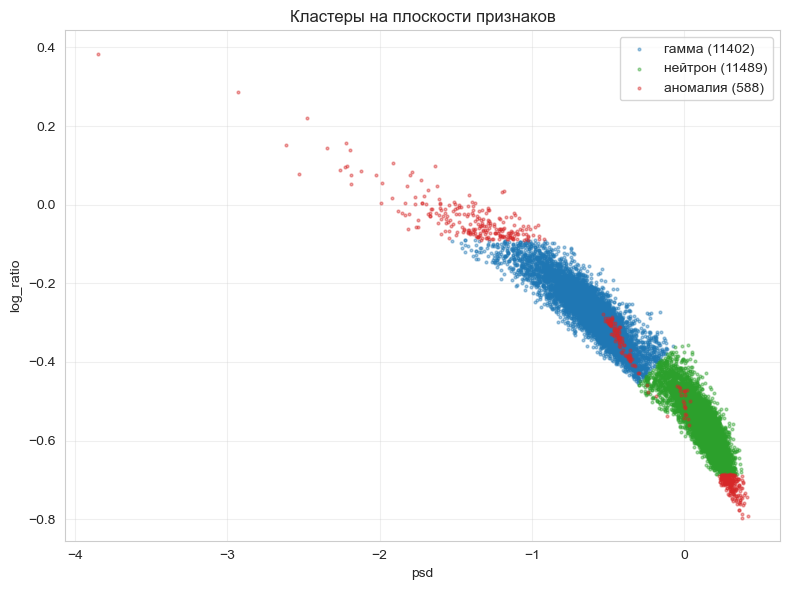

In [18]:
colors = {0: 'tab:blue', 1: 'tab:green', 2: 'tab:red'}
names = {0: 'гамма', 1: 'нейтрон', 2: 'аномалия'}
plt.figure(figsize=(8, 6))

for c in [0, 1, 2]:
    mask = (labels == c)

    plt.scatter(
        features['psd'][mask],
        features['log_ratio'][mask],
        s=4, alpha=0.4,
        c=colors[c],
        label=f'{names[c]} ({mask.sum()})'
    )

plt.xlabel('psd')
plt.ylabel('log_ratio')
plt.title('Кластеры на плоскости признаков')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

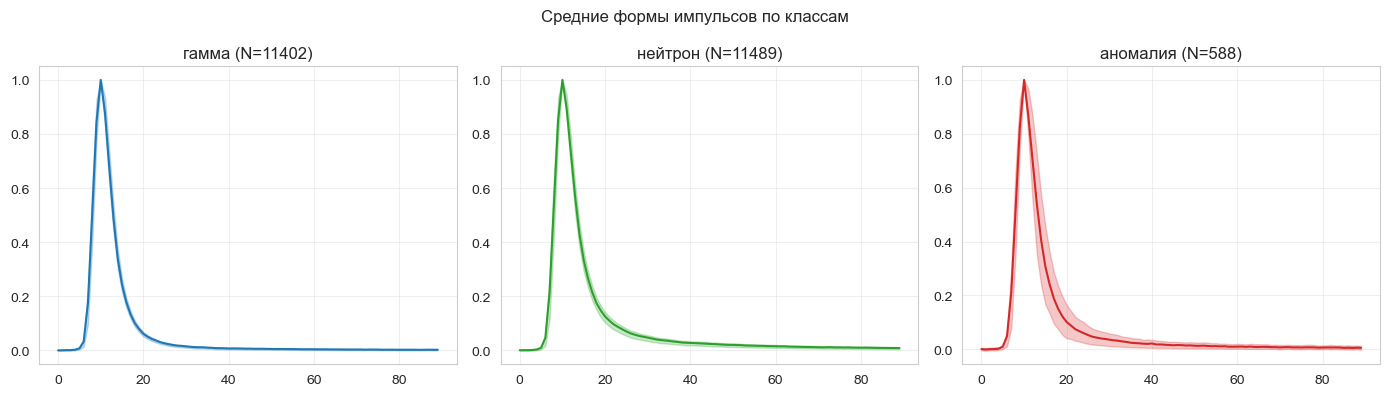

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, c in zip(axes, [0, 1, 2]):

    mask = (labels == c)
    if mask.sum() == 0:
        continue

    waves_c = X_signal[mask]

    baseline = waves_c[:, :NOISE_WINDOW].mean(axis=1, keepdims=True)
    sub = waves_c - baseline

    peaks = sub.argmax(axis=1)

    win = 80
    aligned = []

    for i in range(min(2000, len(sub))):
        p = peaks[i]

        a = max(0, p - 10)
        b = min(sub.shape[1], p + win)

        seg = sub[i, a:b]

        if len(seg) < 20:
            continue

        seg = seg / (seg.max() + 1e-9)

        if len(seg) == (win + 10):
            aligned.append(seg)

    aligned = np.array(aligned)

    if len(aligned) == 0:
        continue

    ax.plot(aligned.mean(axis=0), color=colors[c])
    ax.fill_between(
        np.arange(aligned.shape[1]),
        np.percentile(aligned, 25, axis=0),
        np.percentile(aligned, 75, axis=0),
        color=colors[c], alpha=0.25
    )

    ax.set_title(f'{names[c]} (N={mask.sum()})')
    ax.grid(alpha=0.3)

plt.suptitle('Средние формы импульсов по классам')
plt.tight_layout()
plt.show()

## Подготовка submission

In [20]:
def reorder_by_appearance(labels_array):
    mapping = {}
    new_labels = np.empty_like(labels_array)
    next_label = 0
    for i, val in enumerate(labels_array):
        if val not in mapping:
            mapping[val] = next_label
            next_label += 1
        new_labels[i] = mapping[val]
    return new_labels

final_labels = reorder_by_appearance(labels)

submission = pd.DataFrame({'index': np.arange(N), 'cluster': final_labels})
submission.to_csv('submission.csv', index=False)
print('Файл submission.csv сохранён.')
print(submission.head())

Файл submission.csv сохранён.
   index  cluster
0      0        0
1      1        1
2      2        1
3      3        0
4      4        1


## Выводы

* Проведён полный цикл анализа данных: от загрузки и визуализации до построения физически интерпретируемых признаков (PSD).
* Разведочный анализ подтвердил бимодальность psd и наличие аномалий по log_ratio.
* Сравнение моделей (K-Means, GMM, агломеративная кластеризация) показало, что наилучшее качество достигается при K-Means с двумя кластерами.
* Аномалии корректно выделены по насыщению АЦП и квантилю log_ratio.
* Итоговая модель обеспечивает устойчивое разделение гамма-квантов и нейтронов при предварительной фильтрации аномалий.